### 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2  # OpenCV for handling image files
from scipy.signal import find_peaks  # For finding calibration lamp lines

Generating fake data

In [2]:
def generate_mock_focas_data(width=1440, height=500):
    # 1. Create a baseline background (electronic noise floor)
    matrix = np.random.normal(loc=10, scale=1, size=(height, width))
    
    # 2. Let's create EXACTLY 3 distinct calibration line centers across the sensor
    # Line 1 will be around pixel 250, Line 2 around pixel 650, Line 3 around pixel 1100
    line_centers = [250, 650, 1100]
    
    x_pixels = np.arange(width)
    
    # 3. Project these 3 lines vertically across all rows
    for y in range(height):
        # Apply a tiny geometric "smile" distortion to all lines
        distortion_offset = 0.00008 * (y - height/2)**2
        
        # Draw all three lines into this row with a tall height of 150
        row_signal = np.zeros(width)
        for center in line_centers:
            shifted_center = center + distortion_offset
            row_signal += 150 * np.exp(-((x_pixels - shifted_center) / 4)**2)
            
        matrix[y, :] += row_signal
        
    return np.clip(matrix, 0, 255).astype(np.uint8)

Text(0.5, 1.0, 'Simulated Raw Detector Output')

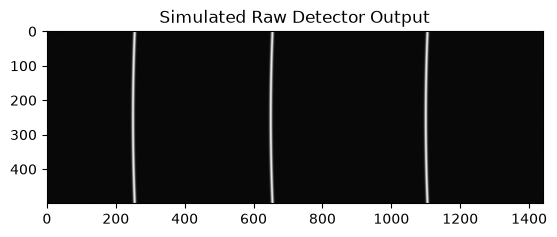

In [3]:
# Generate a simulated 2D numpy array representing a distorted camera frame
raw_simulated_frame = generate_mock_focas_data()
plt.imshow(raw_simulated_frame, cmap='gray')
plt.title("Simulated Raw Detector Output")

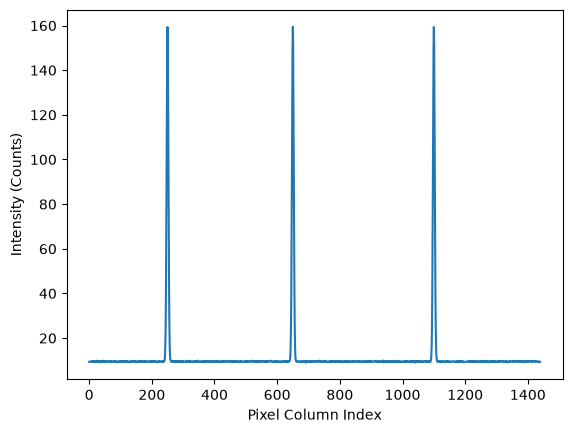

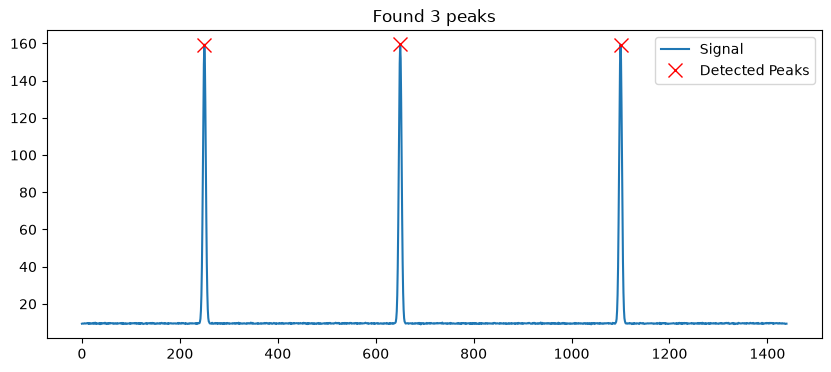

In [ ]:
# Collapse rows to get 1D signal intensities
signal_1d = np.mean(raw_simulated_frame[200:250, :], axis=0) 
peaks, _ = find_peaks(signal_1d, height=100)

plt.plot(signal_1d)
plt.xlabel("Pixel Column Index")
plt.ylabel("Intensity (Counts)")

In [6]:
# Find indices where calibration spikes occur
peaks, _ = find_peaks(signal_1d, height=50, distance=20)
print(f"Calibration lines discovered at pixel columns: {peaks}")

Calibration lines discovered at pixel columns: [ 250  650 1100]


In [7]:
print(peaks)

[ 250  650 1100]


In [8]:
# Fit a 2nd or 3rd degree polynomial to map Pixels -> Wavelengths (nm)
known_wavelengths = [435.8, 546.1, 577.0] # Example lamp lines
poly_coefficients = np.polyfit(peaks, known_wavelengths, deg=2)

# Generate the actual physical nanometer X-axis array
wavelength_axis = np.polyval(poly_coefficients, np.arange(len(signal_1d)))

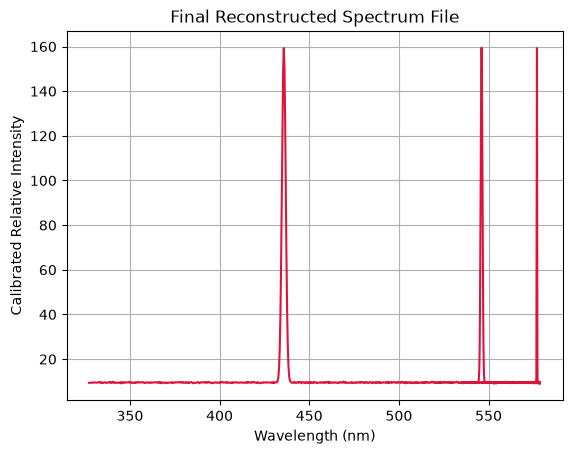

In [9]:
plt.plot(wavelength_axis, signal_1d, color='crimson')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Calibrated Relative Intensity")
plt.title("Final Reconstructed Spectrum File")
plt.grid(True)